In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv"

df = pd.read_csv(url)

df.head()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


In [ ]:
df = df.drop(columns=["Id"], errors="ignore")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [ ]:
df = df.drop_duplicates()

In [ ]:
df=df.fillna(df.mean())


In [ ]:
df

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0
3,6,8,8,1,3,4.0,3,7,1,0
4,4,1,1,3,2,1.0,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
693,3,1,1,1,2,1.0,2,1,2,0
694,3,1,1,1,3,2.0,1,1,1,0
696,5,10,10,3,7,3.0,8,10,2,1
697,4,8,6,4,3,4.0,10,6,1,1


In [ ]:
df["Mitoses"].value_counts()

,count
Mitoses,
1,344
2,35
3,32
10,14
4,12
7,9
8,8
5,6
6,3


In [ ]:
df.isna().sum()

,0
Cl.thickness,0
Cell.size,0
Cell.shape,0
Marg.adhesion,0
Epith.c.size,0
Bare.nuclei,0
Bl.cromatin,0
Normal.nucleoli,0
Mitoses,0
Class,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Class"] = le.fit_transform(df["Class"])
df_encoded = pd.get_dummies(df)

In [ ]:
df_encoded

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,0
1,5,4,4,5,7,10.0,3,2,1,0
2,3,1,1,1,2,2.0,3,1,1,0
3,6,8,8,1,3,4.0,3,7,1,0
4,4,1,1,3,2,1.0,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...
693,3,1,1,1,2,1.0,2,1,2,0
694,3,1,1,1,3,2.0,1,1,1,0
696,5,10,10,3,7,3.0,8,10,2,1
697,4,8,6,4,3,4.0,10,6,1,1


In [ ]:
X=df.drop(columns=["Class"])
Y=df["Class"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.svm import SVC

In [ ]:
model =SVC(
    kernel='rbf',
    probability=True
)
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.9712230215827338


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'degree': [2, 3]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 1, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}
Best Score: 0.9692710892710894


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


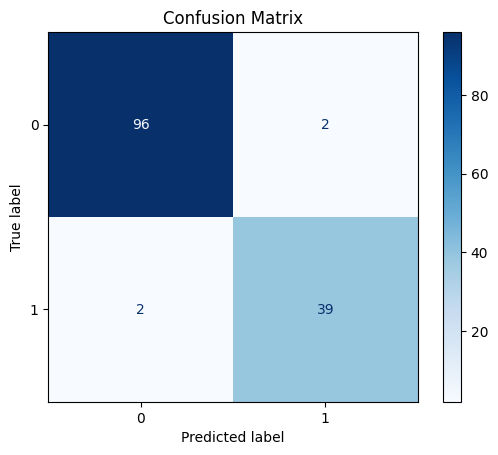

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC Score:", auc)

Accuracy : 0.9712230215827338
Precision: 0.9512195121951219
Recall   : 0.9512195121951219
F1 Score : 0.9512195121951219
AUC Score: 0.9965156794425087


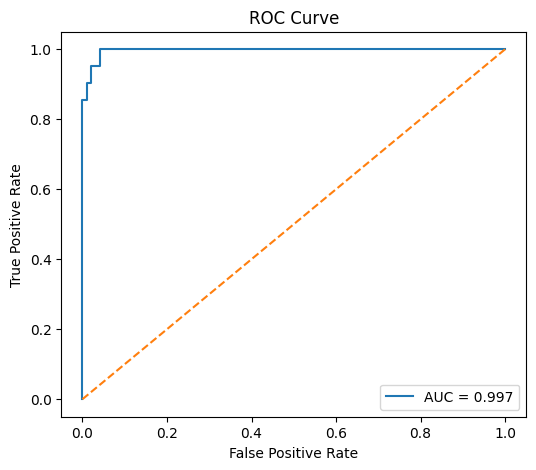

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()


In [ ]:
# Sample Prediction
results = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": y_pred[:10],
    "Probability": y_prob[:10]
})

print("\nSample Predictions:\n")
print(results)


Sample Predictions:

     Actual  Predicted  Probability
386       1          1     0.980415
682       0          0     0.006520
261       1          1     0.954057
344       1          1     0.962790
324       0          0     0.003085
212       0          0     0.003085
387       0          0     0.019330
176       0          0     0.002592
341       0          0     0.003085
260       1          1     0.962336


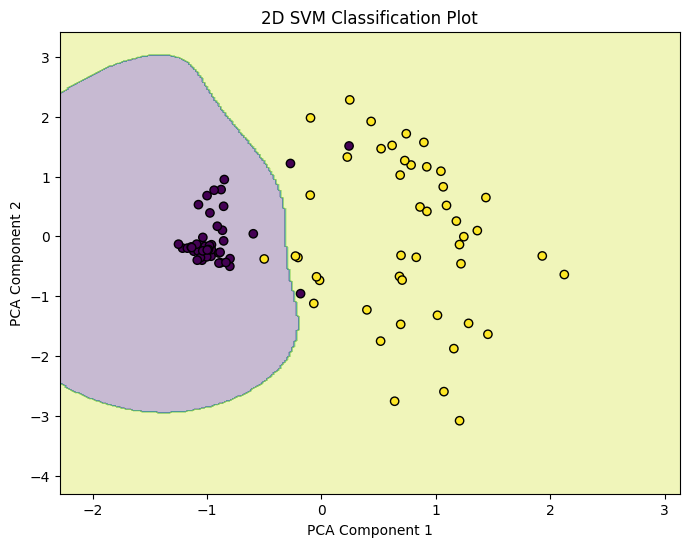

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_pca, Y, test_size=0.2, random_state=42)

scaler2 = StandardScaler()

X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

model2 = SVC(kernel='rbf')

model2.fit(X_train2, y_train2)
x_min, x_max = X_train2[:, 0].min() - 1, X_train2[:, 0].max() + 1
y_min, y_max = X_train2[:, 1].min() - 1, X_train2[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_test2[:, 0],
    X_test2[:, 1],
    c=y_test2,
    edgecolors='k'
)

plt.title("2D SVM Classification Plot")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()